In [10]:
import math
import heapq
import time
import json
import random
from pathlib import Path
from typing import Callable

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import osmnx as ox
from IPython.display import display

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# OSMnx runtime settings
ox.settings.use_cache = True
ox.settings.log_console = False

def _resolve_project_root_for_cache() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'backend').exists() and (cwd / 'notebooks').exists():
        return cwd
    if (cwd.parent / 'backend').exists() and (cwd.parent / 'notebooks').exists():
        return cwd.parent
    return cwd

_runtime_project_root = _resolve_project_root_for_cache()
_runtime_http_cache_dir = _runtime_project_root / 'cache' / 'http_osmnx'
_runtime_http_cache_dir.mkdir(parents=True, exist_ok=True)
ox.settings.cache_folder = str(_runtime_http_cache_dir)


In [11]:
# 1) Data setup: cache metadata helpers + PEMS-BAY 

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'backend').exists() and (cwd / 'notebooks').exists():
        return cwd
    if (cwd.parent / 'backend').exists() and (cwd.parent / 'notebooks').exists():
        return cwd.parent
    return cwd


project_root = resolve_project_root()
cache_dir = project_root / 'cache'
http_cache_dir = cache_dir / 'http_osmnx'
legacy_http_cache_dir = project_root / 'notebooks' / 'cache'


def prune_json_cache(cache_path: Path, max_files: int) -> None:
    if not cache_path.exists():
        return
    files = [p for p in cache_path.rglob('*.json') if p.is_file()]
    if not files:
        return

    files = [p for p in cache_path.rglob('*.json') if p.is_file()]
    if len(files) <= max_files:
        return
    files.sort(key=lambda p: p.stat().st_mtime)
    for p in files[: max(0, len(files) - max_files)]:
        try:
            p.unlink(missing_ok=True)
        except OSError:
            pass


prune_json_cache(http_cache_dir, max_files=160)
prune_json_cache(legacy_http_cache_dir, max_files=80)


def read_cache_bbox(cache_path: Path):
    if not cache_path.exists():
        return None
    try:
        obj = json.loads(cache_path.read_text(encoding='utf-8'))
        meta = obj.get('meta', {}) if isinstance(obj, dict) else {}
        bbox = meta.get('bbox', {}) if isinstance(meta, dict) else {}
        s = float(bbox.get('south'))
        w = float(bbox.get('west'))
        n = float(bbox.get('north'))
        e = float(bbox.get('east'))
        return (s, w, n, e)
    except Exception:
        return None


def point_in_bbox(lat: float, lng: float, bbox, pad: float = 0.0) -> bool:
    s, w, n, e = bbox
    return (s - pad) <= lat <= (n + pad) and (w - pad) <= lng <= (e + pad)


def pair_inside_bbox(start_coord: tuple[float, float], end_coord: tuple[float, float], bbox, pad: float = 0.0) -> bool:
    return point_in_bbox(start_coord[0], start_coord[1], bbox, pad=pad) and point_in_bbox(end_coord[0], end_coord[1], bbox, pad=pad)


def geocode_or_fallback(address: str, fallback: tuple[float, float]) -> tuple[float, float, str]:
    try:
        lat, lng = ox.geocode(address)
        return float(lat), float(lng), 'geocode'
    except Exception:
        return float(fallback[0]), float(fallback[1]), 'fallback'


# Default comparison route (user case)
DEFAULT_START_ADDRESS = 'vul. Boholiubova 25, Sofiivska Borshchahivka, Kyiv Oblast, Ukraine'
DEFAULT_END_ADDRESS = 'Oleksy Tykhoho light rail station, Kyiv, Ukraine'
DEFAULT_START_FALLBACK = (50.4097, 30.3685)
DEFAULT_END_FALLBACK = (50.4448, 30.4316)

# PEMS-BAY files
traffic_dir = project_root / 'data' / 'traffic_data'
graph_dir = project_root / 'data' / 'sensor_graph'

speed_path = traffic_dir / 'speed.csv'
occ_path = traffic_dir / 'occupancy.csv'
meta_path = graph_dir / 'sensor_metadata.csv'
dist_path = graph_dir / 'distances_bay_2017.csv'

if not speed_path.exists() or not occ_path.exists() or not dist_path.exists() or not meta_path.exists():
    raise FileNotFoundError('PEMS-BAY files are missing in data/traffic_data or data/sensor_graph')

speed_raw = pd.read_csv(speed_path)
occ_raw = pd.read_csv(occ_path)
meta_raw = pd.read_csv(meta_path)
dist_raw = pd.read_csv(dist_path)

sensor_ids_all = speed_raw.iloc[:, 0].astype(str).tolist()
time_columns = list(speed_raw.columns[1:])
timestamps = pd.to_datetime(time_columns, errors='raise')

speed_values_all = speed_raw.iloc[:, 1:].to_numpy(dtype=np.float32)

occ_sensor_col = occ_raw.columns[0]
occ_raw[occ_sensor_col] = occ_raw[occ_sensor_col].astype(str)
occ_raw = occ_raw.set_index(occ_sensor_col)
occ_values_all = occ_raw.loc[sensor_ids_all, time_columns].to_numpy(dtype=np.float32)


def fill_missing_by_sensor_mean(values: np.ndarray) -> np.ndarray:
    arr = values.astype(np.float32, copy=True)
    row_mean = np.nanmean(arr, axis=1, keepdims=True)
    row_mean = np.where(np.isfinite(row_mean), row_mean, 0.0)
    bad = ~np.isfinite(arr)
    if np.any(bad):
        fallback = np.repeat(row_mean, arr.shape[1], axis=1)
        arr[bad] = fallback[bad]
    return arr


speed_values_all = fill_missing_by_sensor_mean(speed_values_all)
occ_values_all = fill_missing_by_sensor_mean(occ_values_all)

meta_raw['Sensor ID'] = meta_raw['Sensor ID'].astype(str)
meta_map = meta_raw.set_index('Sensor ID')[['Latitude', 'Longitude']].to_dict('index')
lat_values = meta_raw['Latitude'].astype(np.float64).to_numpy()
lng_values = meta_raw['Longitude'].astype(np.float64).to_numpy()
lat_fallback = float(np.nanmean(lat_values))
lng_fallback = float(np.nanmean(lng_values))

sensor_mean_mph_all = np.mean(speed_values_all, axis=1).astype(np.float32)
global_speed_mph = float(np.mean(sensor_mean_mph_all))

id_to_idx_all = {sid: i for i, sid in enumerate(sensor_ids_all)}
dist_raw['from'] = dist_raw['from'].astype(str)
dist_raw['to'] = dist_raw['to'].astype(str)
dist_raw['distance'] = dist_raw['distance'].astype(np.float32)

valid_dist = dist_raw[
    (dist_raw['distance'] > 0)
    & dist_raw['from'].isin(id_to_idx_all)
    & dist_raw['to'].isin(id_to_idx_all)
]
if valid_dist.empty:
    raise RuntimeError('No valid sensor distances found in distances_bay_2017.csv')

G_pems = nx.DiGraph()
for sid in sensor_ids_all:
    meta_row = meta_map.get(sid)
    if meta_row is None:
        lat, lng = lat_fallback, lng_fallback
    else:
        lat = float(meta_row.get('Latitude', lat_fallback))
        lng = float(meta_row.get('Longitude', lng_fallback))
        if not np.isfinite(lat):
            lat = lat_fallback
        if not np.isfinite(lng):
            lng = lng_fallback
    G_pems.add_node(sid, lat=lat, lng=lng)

for src, dst, distance_m in valid_dist[['from', 'to', 'distance']].itertuples(index=False, name=None):
    src, dst = str(src), str(dst)
    if src == dst:
        continue

    i = id_to_idx_all[src]
    j = id_to_idx_all[dst]
    sp_u_mph = float(sensor_mean_mph_all[i]) if np.isfinite(sensor_mean_mph_all[i]) else global_speed_mph
    sp_v_mph = float(sensor_mean_mph_all[j]) if np.isfinite(sensor_mean_mph_all[j]) else global_speed_mph
    edge_speed_mph = max(5.0, 0.5 * (sp_u_mph + sp_v_mph))
    edge_speed_mps = edge_speed_mph * 0.44704
    free_flow_time = float(distance_m) / max(edge_speed_mps, 1e-6)

    G_pems.add_edge(src, dst, length_m=float(distance_m), free_flow_time=free_flow_time, baseline_speed_mph=edge_speed_mph)

largest_wcc = max(nx.weakly_connected_components(G_pems), key=len)
G_pems = G_pems.subgraph(largest_wcc).copy()

sensor_ids = list(G_pems.nodes)
idx_keep = [id_to_idx_all[sid] for sid in sensor_ids]
speed_values = speed_values_all[idx_keep, :]
occ_values = occ_values_all[idx_keep, :]

print('PEMS graph loaded:')
print('  nodes:', G_pems.number_of_nodes(), 'edges:', G_pems.number_of_edges())
print('  speed matrix:', speed_values.shape, 'occupancy matrix:', occ_values.shape)
print('  time range:', str(timestamps[0]), '->', str(timestamps[-1]))

for cache_name in ['osm_kyiv_core.json', 'osm_kyiv_plus5km.json']:
    cpath = cache_dir / cache_name
    bbox = read_cache_bbox(cpath)
    print('cache:', cache_name, '| exists=', cpath.exists(), '| bbox=', bbox)


PEMS graph loaded:
  nodes: 321 edges: 8033
  speed matrix: (321, 52116) occupancy matrix: (321, 52116)
  time range: 2017-01-01 00:00:00 -> 2017-06-30 23:55:00
cache: osm_kyiv_core.json | exists= True | bbox= (50.406, 30.3645, 50.4622, 30.4346)
cache: osm_kyiv_plus5km.json | exists= True | bbox= (50.360954954954956, 30.293781791296546, 50.507245045045046, 30.505318208703454)


## 2. Класичні алгоритми: A* та ALT



In [12]:
def euclidean_time_heuristic(G: nx.DiGraph, a, b, speed_mps: float = 15.0) -> float:
    lat1, lng1 = G.nodes[a]['lat'], G.nodes[a]['lng']
    lat2, lng2 = G.nodes[b]['lat'], G.nodes[b]['lng']
    return math.hypot(lat2-lat1, lng2-lng1) * 111000.0 / speed_mps

def manhattan_time_heuristic(G: nx.DiGraph, a, b, speed_mps: float = 15.0) -> float:
    lat1, lng1 = G.nodes[a]['lat'], G.nodes[a]['lng']
    lat2, lng2 = G.nodes[b]['lat'], G.nodes[b]['lng']
    return (abs(lat2-lat1) + abs(lng2-lng1)) * 111000.0 / speed_mps

def prepare_alt_landmarks(G: nx.DiGraph, landmarks: list, weight_key: str = 'free_flow_time'):
    forward = {}
    reverse = {}
    rev = G.reverse(copy=False)
    for lm in landmarks:
        forward[lm] = nx.single_source_dijkstra_path_length(G, lm, weight=weight_key)
        reverse[lm] = nx.single_source_dijkstra_path_length(rev, lm, weight=weight_key)
    return forward, reverse

def alt_heuristic(node, goal, landmarks, forward, reverse) -> float:
    lb = 0.0
    for lm in landmarks:
        d_lm_goal = forward[lm].get(goal, 0.0)
        d_lm_node = forward[lm].get(node, 0.0)
        d_node_lm = reverse[lm].get(node, 0.0)
        d_goal_lm = reverse[lm].get(goal, 0.0)
        lb = max(lb, d_lm_goal-d_lm_node, d_node_lm-d_goal_lm, 0.0)
    return lb

def a_star_with_metrics(G, source, target, weight_key, heuristic_fn: Callable):
    started = time.perf_counter()
    open_heap = [(heuristic_fn(source, target), 0.0, source)]
    came_from = {}
    g_score = {source: 0.0}
    closed = set()
    expanded = 0

    while open_heap:
        _, curr_g, current = heapq.heappop(open_heap)
        if current in closed:
            continue
        closed.add(current)
        expanded += 1
        if current == target:
            break
        for nbr, edge_data in G[current].items():
            tentative = curr_g + float(edge_data[weight_key])
            if tentative < g_score.get(nbr, float('inf')):
                came_from[nbr] = current
                g_score[nbr] = tentative
                f_score = tentative + heuristic_fn(nbr, target)
                heapq.heappush(open_heap, (f_score, tentative, nbr))

    if target not in came_from and target != source:
        raise RuntimeError('No route found')

    path = [target]
    cur = target
    while cur != source:
        cur = came_from[cur]
        path.append(cur)
    path.reverse()

    elapsed_ms = (time.perf_counter() - started) * 1000.0
    dist_m, t_s = 0.0, 0.0
    for u, v in zip(path[:-1], path[1:]):
        dist_m += float(G[u][v]['length_m'])
        t_s += float(G[u][v][weight_key])

    return {
        'path': path,
        'distance_km': dist_m/1000.0,
        'time_min': t_s/60.0,
        'expanded_nodes': expanded,
        'execution_ms': elapsed_ms,
    }

In [13]:
# Routing helper functions (execution will be in section 6)

def can_reach_overpass(host: str = 'overpass-api.de', port: int = 443, timeout_sec: float = 2.0) -> bool:
    import socket
    try:
        with socket.create_connection((host, port), timeout=timeout_sec):
            return True
    except OSError:
        return False


def haversine_m(lat1, lon1, lat2, lon2):
    r = 6371000.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return r * c


def build_graph_from_overpass_json(cache_path: Path) -> nx.DiGraph:
    obj = json.loads(cache_path.read_text(encoding='utf-8'))
    elements = obj.get('elements', []) if isinstance(obj, dict) else []

    node_coords = {}
    for el in elements:
        if el.get('type') == 'node' and 'lat' in el and 'lon' in el:
            node_coords[int(el['id'])] = (float(el['lat']), float(el['lon']))

    graph = nx.DiGraph()
    for node_id, (lat, lng) in node_coords.items():
        graph.add_node(node_id, lat=lat, lng=lng)

    default_speed_kmh = {
        'motorway': 90, 'motorway_link': 60,
        'trunk': 80, 'trunk_link': 50,
        'primary': 60, 'primary_link': 45,
        'secondary': 50, 'secondary_link': 40,
        'tertiary': 40, 'tertiary_link': 35,
        'residential': 30, 'unclassified': 30, 'living_street': 20,
    }

    allowed = set(default_speed_kmh.keys())

    center_lat = float(np.mean([d['lat'] for _, d in graph.nodes(data=True)])) if graph.number_of_nodes() else 50.4501
    center_lng = float(np.mean([d['lng'] for _, d in graph.nodes(data=True)])) if graph.number_of_nodes() else 30.5234

    for el in elements:
        if el.get('type') != 'way':
            continue
        tags = el.get('tags') or {}
        highway = str(tags.get('highway', '')).strip().lower()
        if highway not in allowed:
            continue

        way_nodes = [int(x) for x in (el.get('nodes') or [])]
        if len(way_nodes) < 2:
            continue

        speed_kmh = default_speed_kmh.get(highway, 30)
        raw_maxspeed = str(tags.get('maxspeed', '')).strip()
        if raw_maxspeed:
            import re
            m = re.search(r'\d+(?:\.\d+)?', raw_maxspeed)
            if m:
                speed_kmh = max(10.0, float(m.group(0)))

        speed_mps = max(3.0, speed_kmh / 3.6)

        oneway_val = str(tags.get('oneway', '')).strip().lower()
        oneway = oneway_val in {'yes', '1', 'true'} or str(tags.get('junction', '')).strip().lower() == 'roundabout' or highway in {'motorway', 'motorway_link'}
        reverse_oneway = oneway_val == '-1'

        for a, b in zip(way_nodes[:-1], way_nodes[1:]):
            if a not in node_coords or b not in node_coords:
                continue
            lat1, lng1 = node_coords[a]
            lat2, lng2 = node_coords[b]
            length_m = haversine_m(lat1, lng1, lat2, lng2)
            if length_m <= 0:
                continue

            free_flow = length_m / speed_mps
            radial = math.hypot((lat1 - center_lat) / 0.20, (lng1 - center_lng) / 0.25)
            centrality = max(0.15, 1.0 - min(1.0, radial))

            payload = {
                'length_m': length_m,
                'free_flow_time': free_flow,
                'speed_kph': speed_kmh,
                'centrality': centrality,
                'highway': highway,
            }

            def add_best_edge(u, v, payload_data):
                if graph.has_edge(u, v):
                    if payload_data['free_flow_time'] < float(graph[u][v]['free_flow_time']):
                        graph[u][v].update(payload_data)
                else:
                    graph.add_edge(u, v, **payload_data)

            if reverse_oneway:
                add_best_edge(b, a, payload)
            else:
                add_best_edge(a, b, payload)
                if not oneway:
                    add_best_edge(b, a, payload)

    if graph.number_of_nodes() == 0 or graph.number_of_edges() == 0:
        raise RuntimeError(f'Routing graph is empty for cache {cache_path.name}')

    largest = max(nx.weakly_connected_components(graph), key=len)
    graph = graph.subgraph(largest).copy()
    return graph


_GRAPH_CACHE_MEM = {}

def load_graph_for_bbox(south: float, west: float, north: float, east: float) -> tuple[nx.DiGraph, Path]:
    core_path = cache_dir / 'osm_kyiv_core.json'
    plus5_path = cache_dir / 'osm_kyiv_plus5km.json'

    core_bbox = read_cache_bbox(core_path)
    plus5_bbox = read_cache_bbox(plus5_path)

    # priority: the smallest cache that still covers both points
    selected = None
    if core_bbox is not None and point_in_bbox(south, west, core_bbox, pad=0.0) and point_in_bbox(north, east, core_bbox, pad=0.0):
        selected = core_path
    elif plus5_bbox is not None and point_in_bbox(south, west, plus5_bbox, pad=0.0) and point_in_bbox(north, east, plus5_bbox, pad=0.0):
        selected = plus5_path

    if selected is None:
        # fallback: pick any osm_auto that covers bbox
        import re
        def parse_auto_bbox(path: Path):
            m = re.match(r"^osm_auto_\d+_([\dm\.]+)_([\dm\.]+)_([\dm\.]+)_([\dm\.]+)\.json$", path.name)
            if not m:
                return None
            try:
                s = float(m.group(1).replace('m', '-'))
                w = float(m.group(2).replace('m', '-'))
                n = float(m.group(3).replace('m', '-'))
                e = float(m.group(4).replace('m', '-'))
                return (s, w, n, e)
            except Exception:
                return None

        candidates = []
        for p in cache_dir.glob('osm_auto_*.json'):
            b = parse_auto_bbox(p)
            if b is None:
                continue
            if b[0] <= south and b[1] <= west and b[2] >= north and b[3] >= east:
                area = (b[2] - b[0]) * (b[3] - b[1])
                candidates.append((area, p))

        if candidates:
            candidates.sort(key=lambda x: x[0])
            selected = candidates[0][1]
        else:
            selected = cache_dir / 'osm_full_map.json'

    key = str(selected.resolve())
    if key not in _GRAPH_CACHE_MEM:
        _GRAPH_CACHE_MEM[key] = build_graph_from_overpass_json(selected)

    return _GRAPH_CACHE_MEM[key].copy(), selected


def euclidean_time_heuristic(G: nx.DiGraph, a, b, speed_mps: float = 15.0) -> float:
    lat1, lng1 = G.nodes[a]['lat'], G.nodes[a]['lng']
    lat2, lng2 = G.nodes[b]['lat'], G.nodes[b]['lng']
    return math.hypot(lat2 - lat1, lng2 - lng1) * 111000.0 / speed_mps


def manhattan_time_heuristic(G: nx.DiGraph, a, b, speed_mps: float = 15.0) -> float:
    lat1, lng1 = G.nodes[a]['lat'], G.nodes[a]['lng']
    lat2, lng2 = G.nodes[b]['lat'], G.nodes[b]['lng']
    return (abs(lat2 - lat1) + abs(lng2 - lng1)) * 111000.0 / speed_mps


def prepare_alt_landmarks(G: nx.DiGraph, landmarks: list, weight_key: str = 'free_flow_time'):
    forward = {}
    reverse = {}
    rev = G.reverse(copy=False)
    for lm in landmarks:
        forward[lm] = nx.single_source_dijkstra_path_length(G, lm, weight=weight_key)
        reverse[lm] = nx.single_source_dijkstra_path_length(rev, lm, weight=weight_key)
    return forward, reverse


def alt_heuristic(node, goal, landmarks, forward, reverse) -> float:
    lb = 0.0
    for lm in landmarks:
        d_lm_goal = forward[lm].get(goal, 0.0)
        d_lm_node = forward[lm].get(node, 0.0)
        d_node_lm = reverse[lm].get(node, 0.0)
        d_goal_lm = reverse[lm].get(goal, 0.0)
        lb = max(lb, d_lm_goal - d_lm_node, d_node_lm - d_goal_lm, 0.0)
    return lb


def a_star_with_metrics(G, source, target, weight_key, heuristic_fn: Callable):
    started = time.perf_counter()
    open_heap = [(heuristic_fn(source, target), 0.0, source)]
    came_from = {}
    g_score = {source: 0.0}
    closed = set()
    expanded = 0

    while open_heap:
        _, curr_g, current = heapq.heappop(open_heap)
        if current in closed:
            continue
        closed.add(current)
        expanded += 1
        if current == target:
            break

        for nbr, edge_data in G[current].items():
            if weight_key not in edge_data:
                continue
            tentative = curr_g + float(edge_data[weight_key])
            if tentative < g_score.get(nbr, float('inf')):
                came_from[nbr] = current
                g_score[nbr] = tentative
                f_score = tentative + heuristic_fn(nbr, target)
                heapq.heappush(open_heap, (f_score, tentative, nbr))

    if target not in came_from and target != source:
        raise RuntimeError('No route found')

    path = [target]
    cur = target
    while cur != source:
        cur = came_from[cur]
        path.append(cur)
    path.reverse()

    elapsed_ms = (time.perf_counter() - started) * 1000.0
    dist_m, t_s = 0.0, 0.0
    for u, v in zip(path[:-1], path[1:]):
        dist_m += float(G[u][v].get('length_m', 0.0))
        t_s += float(G[u][v].get(weight_key, 0.0))

    return {
        'path': path,
        'distance_km': dist_m / 1000.0,
        'time_min': t_s / 60.0,
        'expanded_nodes': expanded,
        'execution_ms': elapsed_ms,
    }


def draw_route_simple(G: nx.DiGraph, path: list, title: str = 'Route'):
    xs = [G.nodes[n]['lng'] for n in G.nodes]
    ys = [G.nodes[n]['lat'] for n in G.nodes]

    plt.figure(figsize=(8, 7))
    plt.scatter(xs, ys, s=2, alpha=0.18, label='graph nodes')
    route_x = [G.nodes[n]['lng'] for n in path]
    route_y = [G.nodes[n]['lat'] for n in path]
    plt.plot(route_x, route_y, linewidth=2.5, label='route')
    plt.title(title)
    plt.xlabel('lng')
    plt.ylabel('lat')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()



## 3. Підготовка PEMS-BAY даних для ML

Тут сирі вимірювання PEMS-BAY перетворюються у формат, зручний для навчання моделей.




In [14]:
# Build normalized feature tensors and time splits

def make_time_features(timestamps):
    tod = np.array([ts.hour * 60 + ts.minute for ts in timestamps], dtype=np.float32) / (24.0 * 60.0)
    dow = np.array([ts.dayofweek for ts in timestamps], dtype=np.float32) / 7.0
    tod_sin = np.sin(2.0 * np.pi * tod).astype(np.float32)
    tod_cos = np.cos(2.0 * np.pi * tod).astype(np.float32)
    dow_sin = np.sin(2.0 * np.pi * dow).astype(np.float32)
    dow_cos = np.cos(2.0 * np.pi * dow).astype(np.float32)
    return tod_sin, tod_cos, dow_sin, dow_cos

def build_time_split(num_steps: int, stride: int = 6):
    idx = np.arange(0, num_steps - 1, max(stride, 1), dtype=np.int64)
    n = len(idx)
    tr_end = int(0.7 * n)
    va_end = int(0.85 * n)
    return idx[:tr_end], idx[tr_end:va_end], idx[va_end:]

num_steps = speed_values.shape[1]
time_stride = 6  # 6 * 5min = 30min
train_idx, val_idx, test_idx = build_time_split(num_steps, stride=time_stride)

if len(train_idx) == 0 or len(val_idx) == 0 or len(test_idx) == 0:
    raise RuntimeError('Time split is empty. Use a smaller stride.')

train_horizon_end = int(train_idx[-1]) + 1

speed_mean = float(np.mean(speed_values[:, :train_horizon_end]))
speed_std = float(np.std(speed_values[:, :train_horizon_end]) + 1e-6)
occ_mean = float(np.mean(occ_values[:, :train_horizon_end]))
occ_std = float(np.std(occ_values[:, :train_horizon_end]) + 1e-6)

speed_norm = (speed_values - speed_mean) / speed_std
occ_norm = (occ_values - occ_mean) / occ_std

# Penalty target (models are trained to predict penalty directly)
sensor_free_flow_mph = np.nanpercentile(speed_values[:, :train_horizon_end], 85, axis=1).astype(np.float32)
sensor_free_flow_mph = np.clip(sensor_free_flow_mph, 5.0, None)
penalty_values = np.maximum((sensor_free_flow_mph[:, None] / np.maximum(speed_values, 1e-3)) - 1.0, 0.0)
penalty_values = np.clip(penalty_values, 0.0, 3.0)
target_mean = float(np.mean(penalty_values[:, :train_horizon_end]))
target_std = float(np.std(penalty_values[:, :train_horizon_end]) + 1e-6)
penalty_norm = (penalty_values - target_mean) / target_std

tod_sin, tod_cos, dow_sin, dow_cos = make_time_features(timestamps)

def feature_matrix_for_t(t: int) -> np.ndarray:
    x = np.empty((len(sensor_ids), 6), dtype=np.float32)
    x[:, 0] = speed_norm[:, t]
    x[:, 1] = occ_norm[:, t]
    x[:, 2] = tod_sin[t]
    x[:, 3] = tod_cos[t]
    x[:, 4] = dow_sin[t]
    x[:, 5] = dow_cos[t]
    return x

print('Prepared ML tensors')
print('Sensors:', len(sensor_ids), 'Timesteps:', num_steps)
print('Split sizes (time steps):', len(train_idx), len(val_idx), len(test_idx))
print('speed mean/std:', round(speed_mean, 4), round(speed_std, 4))
print('occ mean/std:', round(occ_mean, 4), round(occ_std, 4))
print('penalty target mean/std:', round(target_mean, 4), round(target_std, 4))


Prepared ML tensors
Sensors: 321 Timesteps: 52116
Split sizes (time steps): 6080 1303 1303
speed mean/std: 62.7106 9.4386
occ mean/std: 0.0568 0.059
penalty target mean/std: 0.1323 0.3864


## 4. Навчання та оцінювання MLP

В цьому блоці навчається MLP, перевіряється якість та зберігаються метрики.



[MLP] epoch=01 train_loss=0.26062 val_loss=0.08604 val_rmse=0.1133 penalty
[MLP] epoch=02 train_loss=0.06320 val_loss=0.06309 val_rmse=0.0971 penalty
[MLP] epoch=03 train_loss=0.04975 val_loss=0.05365 val_rmse=0.0895 penalty
[MLP] epoch=04 train_loss=0.04396 val_loss=0.05059 val_rmse=0.0869 penalty
[MLP] epoch=05 train_loss=0.04161 val_loss=0.04815 val_rmse=0.0848 penalty
[MLP] epoch=06 train_loss=0.04065 val_loss=0.04748 val_rmse=0.0842 penalty
[MLP] epoch=07 train_loss=0.03992 val_loss=0.04700 val_rmse=0.0838 penalty
[MLP] epoch=08 train_loss=0.03961 val_loss=0.04691 val_rmse=0.0837 penalty
[MLP] epoch=09 train_loss=0.03935 val_loss=0.04677 val_rmse=0.0836 penalty
[MLP] epoch=10 train_loss=0.03929 val_loss=0.04691 val_rmse=0.0837 penalty
[MLP] epoch=11 train_loss=0.03897 val_loss=0.04635 val_rmse=0.0832 penalty
[MLP] epoch=12 train_loss=0.03876 val_loss=0.04627 val_rmse=0.0831 penalty
MLP test: loss=0.04584, MAE=0.0337 penalty, RMSE=0.0827 penalty


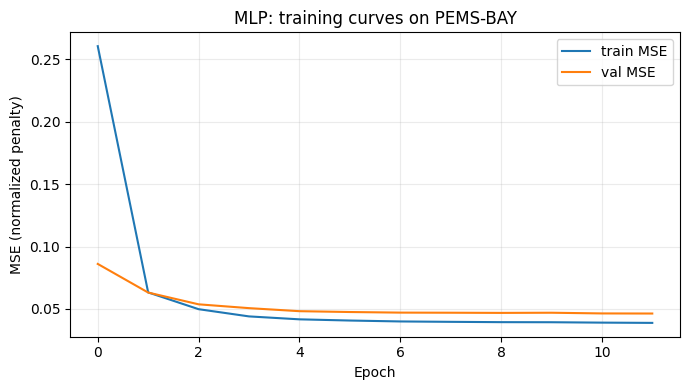

In [15]:
class SensorTimeDataset(Dataset):
    def __init__(self, time_idx: np.ndarray):
        self.time_idx = np.array(time_idx, dtype=np.int64)

    def __len__(self):
        return len(self.time_idx)

    def __getitem__(self, idx):
        t = int(self.time_idx[idx])
        x = feature_matrix_for_t(t)
        y = penalty_norm[:, t + 1].astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y)

train_ds = SensorTimeDataset(train_idx)
val_ds = SensorTimeDataset(val_idx)
test_ds = SensorTimeDataset(test_idx)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

class MLPRegressor(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        # x: [B, N, F]
        return self.net(x).squeeze(-1)

def eval_mlp(model, loader, criterion, device):
    model.eval()
    loss_sum = 0.0
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            loss_sum += float(loss.item()) * xb.shape[0]

            out_denorm = out * target_std + target_mean
            y_denorm = yb * target_std + target_mean
            preds.append(out_denorm.cpu().numpy())
            trues.append(y_denorm.cpu().numpy())

    pred_all = np.concatenate(preds, axis=0)
    true_all = np.concatenate(trues, axis=0)
    mae = float(np.mean(np.abs(pred_all - true_all)))
    rmse = float(np.sqrt(np.mean((pred_all - true_all) ** 2)))
    avg_loss = loss_sum / max(len(loader.dataset), 1)
    return avg_loss, mae, rmse

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mlp_model = MLPRegressor(input_dim=6, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs_mlp = 12
mlp_train_losses = []
mlp_val_losses = []

for epoch in range(1, epochs_mlp + 1):
    mlp_model.train()
    run_loss = 0.0
    seen = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = mlp_model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        run_loss += float(loss.item()) * xb.shape[0]
        seen += xb.shape[0]

    train_loss = run_loss / max(seen, 1)
    val_loss, val_mae, val_rmse = eval_mlp(mlp_model, val_loader, criterion, device)

    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    print(f"[MLP] epoch={epoch:02d} train_loss={train_loss:.5f} val_loss={val_loss:.5f} val_rmse={val_rmse:.4f} penalty")

mlp_test_loss, mlp_test_mae, mlp_test_rmse = eval_mlp(mlp_model, test_loader, criterion, device)
print(f"MLP test: loss={mlp_test_loss:.5f}, MAE={mlp_test_mae:.4f} penalty, RMSE={mlp_test_rmse:.4f} penalty")

plt.figure(figsize=(7, 4))
plt.plot(mlp_train_losses, label='train MSE')
plt.plot(mlp_val_losses, label='val MSE')
plt.title('MLP: training curves on PEMS-BAY')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalized penalty)')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

eval_t = int(test_idx[0])
X_eval = torch.from_numpy(feature_matrix_for_t(eval_t)).unsqueeze(0).to(device)
with torch.no_grad():
    mlp_eval_pred_norm = mlp_model(X_eval).squeeze(0).cpu().numpy()
mlp_eval_pred_penalty = np.clip(mlp_eval_pred_norm * target_std + target_mean, 0.0, None)


## 5. Навчання та оцінювання GNN (GCN)

Тут запускається GCN: модель враховує зв’язки між вузлами і видає прогноз.



[GCN] epoch=01 train_loss=0.53905 val_loss=0.48880 val_rmse=0.2702 penalty
[GCN] epoch=02 train_loss=0.42240 val_loss=0.48161 val_rmse=0.2682 penalty
[GCN] epoch=03 train_loss=0.41941 val_loss=0.48059 val_rmse=0.2679 penalty
[GCN] epoch=04 train_loss=0.41811 val_loss=0.47906 val_rmse=0.2675 penalty
[GCN] epoch=05 train_loss=0.41718 val_loss=0.47778 val_rmse=0.2671 penalty
[GCN] epoch=06 train_loss=0.41613 val_loss=0.47750 val_rmse=0.2670 penalty
[GCN] epoch=07 train_loss=0.41546 val_loss=0.47659 val_rmse=0.2668 penalty
[GCN] epoch=08 train_loss=0.41453 val_loss=0.47549 val_rmse=0.2665 penalty
[GCN] epoch=09 train_loss=0.41414 val_loss=0.47508 val_rmse=0.2663 penalty
[GCN] epoch=10 train_loss=0.41365 val_loss=0.47531 val_rmse=0.2664 penalty
[GCN] epoch=11 train_loss=0.41304 val_loss=0.47473 val_rmse=0.2662 penalty
[GCN] epoch=12 train_loss=0.41289 val_loss=0.47399 val_rmse=0.2660 penalty
GCN test: loss=0.45698, MAE=0.1002 penalty, RMSE=0.2612 penalty


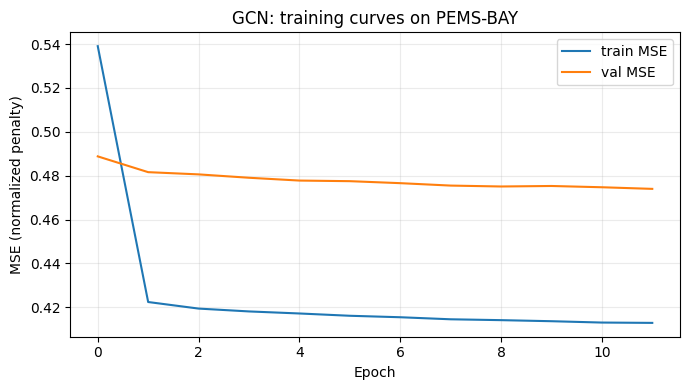

In [16]:
# Build normalized adjacency from PEMS graph 
node_list = list(sensor_ids)
node_to_idx = {n: i for i, n in enumerate(node_list)}
N = len(node_list)

all_lengths = [float(data['length_m']) for _, _, data in G_pems.edges(data=True)]
sigma = float(np.std(all_lengths)) if len(all_lengths) else 1.0
if sigma <= 1e-6:
    sigma = float(np.mean(all_lengths)) if len(all_lengths) else 1.0
if sigma <= 1e-6:
    sigma = 1.0

A = np.zeros((N, N), dtype=np.float32)
for u, v, data in G_pems.edges(data=True):
    i = node_to_idx[u]
    j = node_to_idx[v]
    w = math.exp(-((float(data['length_m']) / sigma) ** 2))
    if w > A[i, j]:
        A[i, j] = w
    if w > A[j, i]:
        A[j, i] = w

A = A + np.eye(N, dtype=np.float32)
D = np.sum(A, axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(D, 1e-8))).astype(np.float32)
A_hat = (D_inv_sqrt @ A @ D_inv_sqrt).astype(np.float32)
A_hat_t = torch.from_numpy(A_hat).to(device)

class GCNRegressor(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, dropout=0.10):
        super().__init__()
        self.lin1 = nn.Linear(input_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, a_hat):
        # x: [B, N, F], a_hat: [N, N]
        h = torch.matmul(a_hat, x)
        h = torch.relu(self.lin1(h))
        h = self.dropout(h)

        h = torch.matmul(a_hat, h)
        h = torch.relu(self.lin2(h))
        h = self.dropout(h)

        h = torch.matmul(a_hat, h)
        y = self.out(h).squeeze(-1)
        return y

def eval_gcn(model, loader, criterion, device, a_hat):
    model.eval()
    loss_sum = 0.0
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            out = model(xb, a_hat)
            loss = criterion(out, yb)
            loss_sum += float(loss.item()) * xb.shape[0]

            out_denorm = out * target_std + target_mean
            y_denorm = yb * target_std + target_mean
            preds.append(out_denorm.cpu().numpy())
            trues.append(y_denorm.cpu().numpy())

    pred_all = np.concatenate(preds, axis=0)
    true_all = np.concatenate(trues, axis=0)
    mae = float(np.mean(np.abs(pred_all - true_all)))
    rmse = float(np.sqrt(np.mean((pred_all - true_all) ** 2)))
    avg_loss = loss_sum / max(len(loader.dataset), 1)
    return avg_loss, mae, rmse

gcn_model = GCNRegressor(input_dim=6, hidden_dim=64, dropout=0.10).to(device)
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=1e-3)
criterion_gcn = nn.MSELoss()

epochs_gcn = 12
gcn_train_losses = []
gcn_val_losses = []

for epoch in range(1, epochs_gcn + 1):
    gcn_model.train()
    run_loss = 0.0
    seen = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = gcn_model(xb, A_hat_t)
        loss = criterion_gcn(pred, yb)

        optimizer_gcn.zero_grad()
        loss.backward()
        optimizer_gcn.step()

        run_loss += float(loss.item()) * xb.shape[0]
        seen += xb.shape[0]

    train_loss = run_loss / max(seen, 1)
    val_loss, val_mae, val_rmse = eval_gcn(gcn_model, val_loader, criterion_gcn, device, A_hat_t)

    gcn_train_losses.append(train_loss)
    gcn_val_losses.append(val_loss)
    print(f"[GCN] epoch={epoch:02d} train_loss={train_loss:.5f} val_loss={val_loss:.5f} val_rmse={val_rmse:.4f} penalty")

gcn_test_loss, gcn_test_mae, gcn_test_rmse = eval_gcn(gcn_model, test_loader, criterion_gcn, device, A_hat_t)
print(f"GCN test: loss={gcn_test_loss:.5f}, MAE={gcn_test_mae:.4f} penalty, RMSE={gcn_test_rmse:.4f} penalty")

plt.figure(figsize=(7, 4))
plt.plot(gcn_train_losses, label='train MSE')
plt.plot(gcn_val_losses, label='val MSE')
plt.title('GCN: training curves on PEMS-BAY')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalized penalty)')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

with torch.no_grad():
    gcn_eval_pred_norm = gcn_model(X_eval, A_hat_t).squeeze(0).cpu().numpy()
gcn_eval_pred_penalty = np.clip(gcn_eval_pred_norm * target_std + target_mean, 0.0, None)


## 6. Порівняння методів




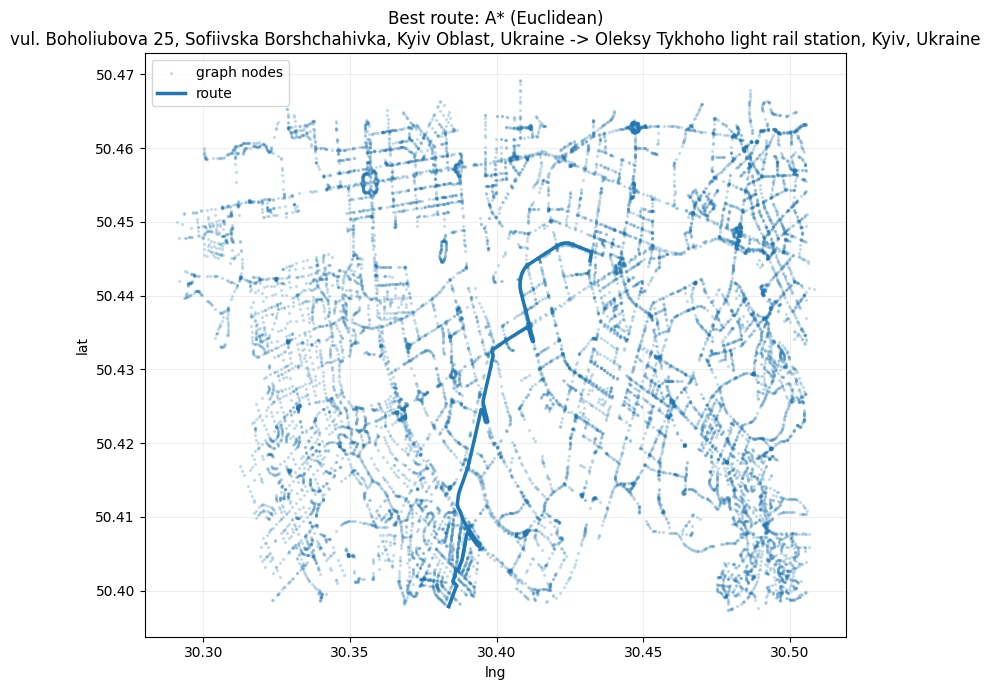

Forecast comparison:


,model,test_mae_penalty,test_rmse_penalty
0,MLP,0.0337,0.0827
1,GCN,0.1002,0.2612


Route context:
{'start': {'label': 'vul. Boholiubova 25, Sofiivska Borshchahivka, Kyiv Oblast, Ukraine', 'coord': (50.3949505, 30.3842631), 'source': 'geocode'}, 'end': {'label': 'Oleksy Tykhoho light rail station, Kyiv, Ukraine', 'coord': (50.4448, 30.4316), 'source': 'fallback'}, 'cache_file': 'C:\\Users\\rosti\\Desktop\\unik\\ші\\cache\\osm_kyiv_plus5km.json', 'graph_nodes': 19376, 'graph_edges': 34290}
Five-method comparison (home -> Oleksy Tykhoho):


,method,distance_km,time_min,expanded_nodes,execution_ms
0,A* (Euclidean),9.7438,12.7397,3430,22.2383
1,ALT,9.7438,12.7397,3074,25.9863
2,A* (Manhattan),9.8738,12.8957,2674,15.3054
3,GCN,9.8738,29.6347,3042,26.5383
4,MLP,10.5378,30.2291,2618,20.0549


In [17]:
# Section 6: compare 5 methods on two points (coords or geocoded addresses)

# --- 1) Build edge times from trained MLP/GCN ---
def apply_mlp_and_gcn_weights(G: nx.DiGraph, ref_t: int):
    mlp_model.eval()

    tod_sin_ref = float(tod_sin[ref_t])
    tod_cos_ref = float(tod_cos[ref_t])
    dow_sin_ref = float(dow_sin[ref_t])
    dow_cos_ref = float(dow_cos[ref_t])

    edges = list(G.edges(data=True))

    # MLP edge inference
    X_edge_rows = []
    for u, v, data in edges:
        length_m = float(data.get('length_m', 0.0) or 0.0)
        free_flow = max(float(data.get('free_flow_time', 1.0) or 1.0), 1e-6)
        speed_mph = (length_m / free_flow) / 0.44704 if length_m > 0.0 else 25.0

        centrality = float(data.get('centrality', 0.5) or 0.5)
        occ_proxy = 0.02 + 0.18 * max(0.0, min(1.0, 1.0 - centrality))

        X_edge_rows.append([
            (speed_mph - speed_mean) / speed_std,
            (occ_proxy - occ_mean) / occ_std,
            tod_sin_ref,
            tod_cos_ref,
            dow_sin_ref,
            dow_cos_ref,
        ])

    X_edge_tensor = torch.tensor(np.asarray(X_edge_rows, dtype=np.float32), dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        mlp_pred_norm = mlp_model(X_edge_tensor).squeeze(0).cpu().numpy()
    mlp_pred_penalty = np.clip(mlp_pred_norm * target_std + target_mean, 0.0, None)

    for (_, _, data), penalty_raw in zip(edges, mlp_pred_penalty):
        free_flow = max(float(data.get('free_flow_time', 1e-6) or 1e-6), 1e-6)
        penalty = float(max(0.0, penalty_raw))
        data['mlp_penalty_coef'] = penalty
        data['mlp_time'] = float(free_flow * (1.0 + penalty))

    # GCN node inference using sparse propagation
    node_ids = [int(node_id) for node_id in G.nodes]
    node_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
    N = len(node_ids)

    node_speed_mph = np.zeros(N, dtype=np.float64)
    node_occ_proxy = np.zeros(N, dtype=np.float64)
    node_count = np.zeros(N, dtype=np.float64)

    for u, v, data in edges:
        ui = node_to_idx[int(u)]
        vi = node_to_idx[int(v)]
        length_m = float(data.get('length_m', 0.0) or 0.0)
        free_flow = max(float(data.get('free_flow_time', 1.0) or 1.0), 1e-6)
        speed_mph = (length_m / free_flow) / 0.44704 if length_m > 0.0 else 25.0

        cent = float(data.get('centrality', 0.5) or 0.5)
        occ_proxy = 0.02 + 0.18 * max(0.0, min(1.0, 1.0 - cent))

        node_speed_mph[ui] += speed_mph
        node_speed_mph[vi] += speed_mph
        node_occ_proxy[ui] += occ_proxy
        node_occ_proxy[vi] += occ_proxy
        node_count[ui] += 1.0
        node_count[vi] += 1.0

    node_count = np.maximum(node_count, 1.0)
    node_speed_mph /= node_count
    node_occ_proxy /= node_count

    X_nodes = np.empty((N, 6), dtype=np.float64)
    X_nodes[:, 0] = (node_speed_mph - speed_mean) / speed_std
    X_nodes[:, 1] = (node_occ_proxy - occ_mean) / occ_std
    X_nodes[:, 2] = tod_sin_ref
    X_nodes[:, 3] = tod_cos_ref
    X_nodes[:, 4] = dow_sin_ref
    X_nodes[:, 5] = dow_cos_ref

    def build_runtime_sparse_adj_norm(graph: nx.DiGraph, node_to_idx_local: dict[int, int]):
        lengths = []
        pair_weight = {}

        for uu, vv, dd in graph.edges(data=True):
            i = node_to_idx_local[int(uu)]
            j = node_to_idx_local[int(vv)]
            if i == j:
                continue
            length = float(dd.get('length_m', 0.0) or 0.0)
            if length > 0.0:
                lengths.append(length)

        sigma = float(np.std(lengths)) if lengths else 1.0
        if sigma <= 1e-6:
            sigma = float(np.mean(lengths)) if lengths else 1.0
        if sigma <= 1e-6:
            sigma = 1.0

        for uu, vv, dd in graph.edges(data=True):
            i = node_to_idx_local[int(uu)]
            j = node_to_idx_local[int(vv)]
            if i == j:
                continue
            length = float(dd.get('length_m', 0.0) or 0.0)
            if length <= 0.0:
                continue
            w = math.exp(-((length / sigma) ** 2))
            a, b = (i, j) if i < j else (j, i)
            prev = pair_weight.get((a, b))
            if prev is None or w > prev:
                pair_weight[(a, b)] = w

        degree = np.ones(len(node_to_idx_local), dtype=np.float64)
        for (i, j), w in pair_weight.items():
            degree[i] += w
            degree[j] += w

        src_idx, dst_idx, edge_coeff = [], [], []
        for (i, j), w in pair_weight.items():
            coeff = w / math.sqrt(max(degree[i] * degree[j], 1e-12))
            src_idx.extend([i, j])
            dst_idx.extend([j, i])
            edge_coeff.extend([coeff, coeff])

        self_coeff = 1.0 / np.maximum(degree, 1e-8)
        return (
            self_coeff.astype(np.float64),
            np.asarray(src_idx, dtype=np.int64),
            np.asarray(dst_idx, dtype=np.int64),
            np.asarray(edge_coeff, dtype=np.float64),
        )

    def sparse_norm_propagate(features: np.ndarray, self_coeff: np.ndarray, src_idx: np.ndarray, dst_idx: np.ndarray, edge_coeff: np.ndarray):
        out = self_coeff[:, None] * features
        if src_idx.size > 0:
            np.add.at(out, src_idx, edge_coeff[:, None] * features[dst_idx])
        return out

    self_coeff, src_idx, dst_idx, edge_coeff = build_runtime_sparse_adj_norm(G, node_to_idx)
    state = {k: v.detach().cpu().numpy() for k, v in gcn_model.state_dict().items()}

    W1 = np.asarray(state['lin1.weight'], dtype=np.float64)
    b1 = np.asarray(state['lin1.bias'], dtype=np.float64).reshape(1, -1)
    W2 = np.asarray(state['lin2.weight'], dtype=np.float64)
    b2 = np.asarray(state['lin2.bias'], dtype=np.float64).reshape(1, -1)
    W_out = np.asarray(state['out.weight'], dtype=np.float64)
    b_out = np.asarray(state['out.bias'], dtype=np.float64).reshape(1, -1)

    Z1 = sparse_norm_propagate(X_nodes, self_coeff, src_idx, dst_idx, edge_coeff)
    H1 = np.maximum(0.0, Z1 @ W1.T + b1)
    Z2 = sparse_norm_propagate(H1, self_coeff, src_idx, dst_idx, edge_coeff)
    H2 = np.maximum(0.0, Z2 @ W2.T + b2)
    Z3 = sparse_norm_propagate(H2, self_coeff, src_idx, dst_idx, edge_coeff)
    gcn_pred_norm = (Z3 @ W_out.T + b_out).reshape(-1)
    gcn_pred_penalty = np.clip(gcn_pred_norm * target_std + target_mean, 0.0, None)

    for u, v, data in edges:
        ui = node_to_idx[int(u)]
        vi = node_to_idx[int(v)]
        free_flow = max(float(data.get('free_flow_time', 1e-6) or 1e-6), 1e-6)
        penalty = 0.5 * (float(gcn_pred_penalty[ui]) + float(gcn_pred_penalty[vi]))
        penalty = float(max(0.0, penalty))
        data['gnn_penalty_coef'] = penalty
        data['gnn_time'] = float(free_flow * (1.0 + penalty))


def resolve_point_input(point_input, fallback=None):
    if isinstance(point_input, str):
        if fallback is None:
            lat, lng = ox.geocode(point_input)
            return float(lat), float(lng), 'geocode', point_input
        lat, lng, source = geocode_or_fallback(point_input, fallback)
        return lat, lng, source, point_input

    if isinstance(point_input, (tuple, list)) and len(point_input) == 2:
        return float(point_input[0]), float(point_input[1]), 'coords', f'{point_input[0]}, {point_input[1]}'

    raise ValueError('Point input must be address string or (lat, lng) tuple.')


def compare_five_methods_between_points(start_input, end_input, start_fallback=None, end_fallback=None, show_map=True):
    s_lat, s_lng, s_src, s_label = resolve_point_input(start_input, fallback=start_fallback)
    e_lat, e_lng, e_src, e_label = resolve_point_input(end_input, fallback=end_fallback)

    south = min(s_lat, e_lat) - 0.003
    north = max(s_lat, e_lat) + 0.003
    west = min(s_lng, e_lng) - 0.003
    east = max(s_lng, e_lng) + 0.003

    G_route, used_cache = load_graph_for_bbox(south=south, west=west, north=north, east=east)

    node_positions = [(n, float(G_route.nodes[n]['lat']), float(G_route.nodes[n]['lng'])) for n in G_route.nodes]
    node_ids = np.array([x[0] for x in node_positions], dtype=np.int64)
    node_lats = np.array([x[1] for x in node_positions], dtype=np.float64)
    node_lngs = np.array([x[2] for x in node_positions], dtype=np.float64)

    def nearest_node(lat, lng):
        dist2 = (node_lats - lat) ** 2 + (node_lngs - lng) ** 2
        return int(node_ids[int(np.argmin(dist2))])

    start_node_local = nearest_node(s_lat, s_lng)
    end_node_local = nearest_node(e_lat, e_lng)

    landmark_candidates = [
        min(node_positions, key=lambda x: x[1] + x[2])[0],
        max(node_positions, key=lambda x: x[1] + x[2])[0],
        min(node_positions, key=lambda x: x[1] - x[2])[0],
        max(node_positions, key=lambda x: x[1] - x[2])[0],
    ]
    landmarks = []
    for lm in landmark_candidates:
        if lm not in landmarks:
            landmarks.append(lm)

    alt_forward, alt_reverse = prepare_alt_landmarks(G_route, landmarks, weight_key='free_flow_time')

    apply_mlp_and_gcn_weights(G_route, ref_t=int(test_idx[0]))

    def build_node_penalty_mean(graph: nx.DiGraph, penalty_key: str):
        sums = {}
        counts = {}
        for uu, vv, dd in graph.edges(data=True):
            node_id = int(uu)
            val = float(dd.get(penalty_key, 0.0) or 0.0)
            sums[node_id] = sums.get(node_id, 0.0) + val
            counts[node_id] = counts.get(node_id, 0) + 1
        out = {}
        for node_id, total in sums.items():
            out[node_id] = float(total / max(counts.get(node_id, 1), 1))
        return out

    mlp_node_penalty = build_node_penalty_mean(G_route, 'mlp_penalty_coef')
    gnn_node_penalty = build_node_penalty_mean(G_route, 'gnn_penalty_coef')

    def ml_penalty_heuristic(graph: nx.DiGraph, a: int, b: int, node_penalty: dict):
        base = euclidean_time_heuristic(graph, a, b)
        p = float(node_penalty.get(int(a), 0.0) or 0.0)
        return base * (1.0 + max(0.0, p))

    method_specs = [
        ('A* (Euclidean)', 'free_flow_time', lambda a, b: euclidean_time_heuristic(G_route, a, b)),
        ('A* (Manhattan)', 'free_flow_time', lambda a, b: manhattan_time_heuristic(G_route, a, b)),
        ('ALT', 'free_flow_time', lambda a, b: alt_heuristic(a, b, landmarks, alt_forward, alt_reverse)),
        ('MLP', 'mlp_time', lambda a, b: ml_penalty_heuristic(G_route, a, b, mlp_node_penalty)),
        ('GCN', 'gnn_time', lambda a, b: ml_penalty_heuristic(G_route, a, b, gnn_node_penalty)),
    ]

    rows = []
    route_paths = {}
    for method_name, weight_key, heur in method_specs:
        res = a_star_with_metrics(G_route, start_node_local, end_node_local, weight_key, heur)
        route_paths[method_name] = res['path']
        rows.append(
            {
                'method': method_name,
                'distance_km': res['distance_km'],
                'time_min': res['time_min'],
                'expanded_nodes': res['expanded_nodes'],
                'execution_ms': res['execution_ms'],
            }
        )

    result_df = pd.DataFrame(rows).sort_values('time_min').reset_index(drop=True).round(4)

    context = {
        'start': {'label': s_label, 'coord': (s_lat, s_lng), 'source': s_src},
        'end': {'label': e_label, 'coord': (e_lat, e_lng), 'source': e_src},
        'cache_file': str(used_cache),
        'graph_nodes': G_route.number_of_nodes(),
        'graph_edges': G_route.number_of_edges(),
    }

    if show_map:
        best_method = str(result_df.iloc[0]['method'])
        draw_route_simple(
            G_route,
            route_paths[best_method],
            title=f'Best route: {best_method}\n{s_label} -> {e_label}',
        )

    return result_df, context


# Required comparison: home -> Oleksy Tykhoho stop
route_compare_df, route_context = compare_five_methods_between_points(
    DEFAULT_START_ADDRESS,
    DEFAULT_END_ADDRESS,
    start_fallback=DEFAULT_START_FALLBACK,
    end_fallback=DEFAULT_END_FALLBACK,
    show_map=True,
)

forecast_compare_df = pd.DataFrame([
    {'model': 'MLP', 'test_mae_penalty': mlp_test_mae, 'test_rmse_penalty': mlp_test_rmse},
    {'model': 'GCN', 'test_mae_penalty': gcn_test_mae, 'test_rmse_penalty': gcn_test_rmse},
]).round(4)

print('Forecast comparison:')
display(forecast_compare_df)

print('Route context:')
print(route_context)

print('Five-method comparison (home -> Oleksy Tykhoho):')
display(route_compare_df)


## 7. Експорт 

Збереження робочих моделей для backend і окремо складає допоміжні артефакти.



In [18]:
# EXPORT_ARTIFACTS 
project_root = resolve_project_root()
model_dir = project_root / 'backend' / 'models'
artifact_dir = project_root / 'data' / 'ml_artifacts' / 'pems_bay'

model_dir.mkdir(parents=True, exist_ok=True)
artifact_dir.mkdir(parents=True, exist_ok=True)

# Save non-model artifacts to data/
pd.DataFrame({'epoch': np.arange(1, len(mlp_train_losses)+1), 'train_loss': mlp_train_losses, 'val_loss': mlp_val_losses}).to_csv(
    artifact_dir / 'pems_mlp_training_curves.csv', index=False
)
pd.DataFrame({'epoch': np.arange(1, len(gcn_train_losses)+1), 'train_loss': gcn_train_losses, 'val_loss': gcn_val_losses}).to_csv(
    artifact_dir / 'pems_gcn_training_curves.csv', index=False
)
forecast_compare_df.to_csv(artifact_dir / 'forecast_comparison.csv', index=False)
route_compare_df.to_csv(artifact_dir / 'route_comparison.csv', index=False)

np.savez_compressed(
    artifact_dir / 'pems_training_meta.npz',
    sensor_ids=np.array(sensor_ids, dtype=object),
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    speed_mean=np.array([speed_mean], dtype=np.float32),
    speed_std=np.array([speed_std], dtype=np.float32),
    occ_mean=np.array([occ_mean], dtype=np.float32),
    occ_std=np.array([occ_std], dtype=np.float32),
    target_mean=np.array([target_mean], dtype=np.float32),
    target_std=np.array([target_std], dtype=np.float32),
)

# Save models to backend/models
mlp_artifact = {
    'model_type': 'pems_mlp_penalty_regressor',
    'feature_names': ['speed_norm', 'occupancy_norm', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos'],
    'speed_mean': speed_mean,
    'speed_std': speed_std,
    'occ_mean': occ_mean,
    'occ_std': occ_std,
    'target_name': 'edge_penalty',
    'target_mean': target_mean,
    'target_std': target_std,
    'state_dict': {k: v.detach().cpu() for k, v in mlp_model.state_dict().items()},
}

gcn_artifact = {
    'model_type': 'pems_gcn_penalty_regressor',
    'feature_names': ['speed_norm', 'occupancy_norm', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos'],
    'sensor_ids': sensor_ids,
    'speed_mean': speed_mean,
    'speed_std': speed_std,
    'occ_mean': occ_mean,
    'occ_std': occ_std,
    'target_name': 'edge_penalty',
    'target_mean': target_mean,
    'target_std': target_std,
    'adjacency_norm': A_hat,
    'state_dict': {k: v.detach().cpu() for k, v in gcn_model.state_dict().items()},
}

torch.save(mlp_artifact, model_dir / 'mlp.pt')
torch.save(gcn_artifact, model_dir / 'gnn.pt')

print('Models saved in backend/models:')
print(' -', model_dir / 'mlp.pt')
print(' -', model_dir / 'gnn.pt')
print('Other artifacts saved in data/:')
print(' -', artifact_dir)


Models saved in backend/models:
 - C:\Users\rosti\Desktop\unik\ші\backend\models\mlp.pt
 - C:\Users\rosti\Desktop\unik\ші\backend\models\gnn.pt
Other artifacts saved in data/:
 - C:\Users\rosti\Desktop\unik\ші\data\ml_artifacts\pems_bay
